In [ ]:
import pickle
from dataloader import DataLoader
from matplotlib import pyplot as plt
import geopandas as gpd
import rasterio.features as rfeatures
import rasterio.transform as rtransform
import numpy as np

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import scipy.signal as sig
import scipy.ndimage as ndimage


In [2]:
with open('data_loaders_v2.pkl', 'rb') as f:
    data_loader = pickle.load(f)

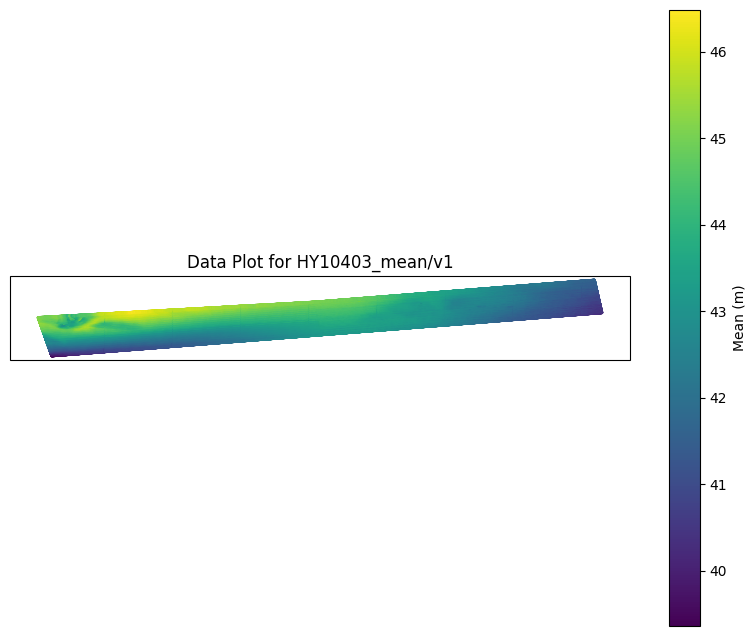

In [28]:
data_loader[4].plot_data()

In [3]:
dl = data_loader[4]
meta = data_loader[4].metadata
id = data_loader[4].id
data = data_loader[4].data

print(data.head())

    Easting   Northing  Mean (m)        Lat       Lon  Easting_N31  \
0  548860.0  5974780.0     39.39  53.919126  3.743956     548860.0   
1  548880.0  5974780.0     39.36  53.919124  3.744260     548880.0   
2  548900.0  5974780.0     39.40  53.919122  3.744565     548900.0   
3  548920.0  5974780.0     39.42  53.919120  3.744869     548920.0   
4  548940.0  5974780.0     39.42  53.919118  3.745174     548940.0   

   Northing_N31  
0     5974780.0  
1     5974780.0  
2     5974780.0  
3     5974780.0  
4     5974780.0  


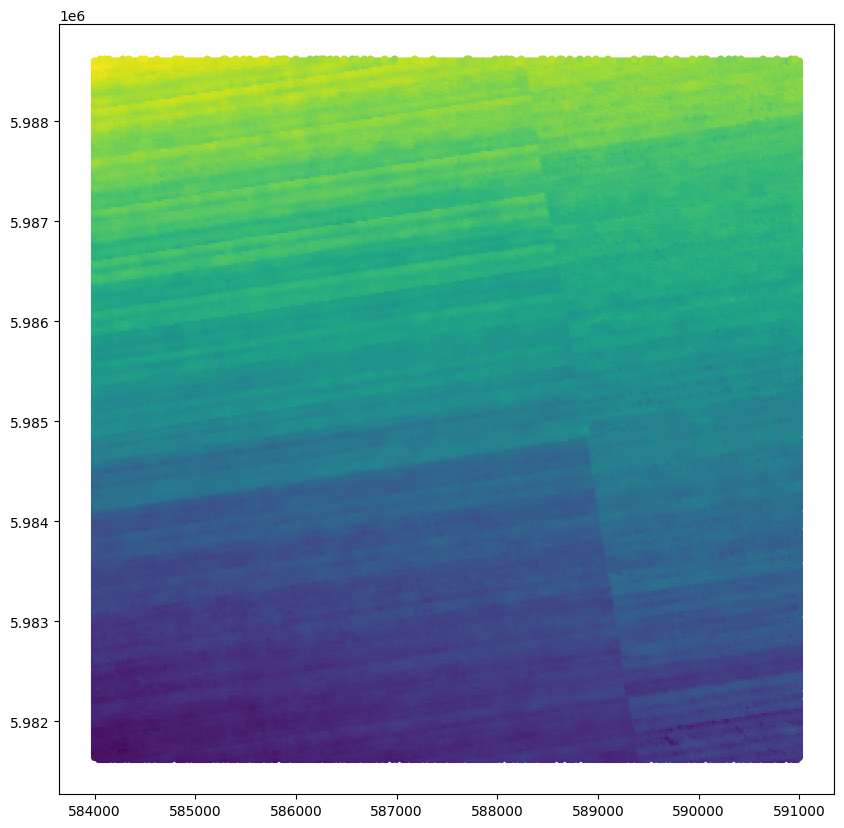

In [4]:
med_nn31, med_en31 = data['Northing_N31'].median(), data['Easting_N31'].median()
bbox = (med_en31 - 3500, med_en31 + 3500, med_nn31 - 3500, med_nn31 + 3500)
points_in_bbox = data[(data['Easting_N31'] >= bbox[0]) & (data['Easting_N31'] <= bbox[1]) & (data['Northing_N31'] >= bbox[2]) & (data['Northing_N31'] <= bbox[3])]
plt.figure(figsize=(10, 10))
plt.scatter(points_in_bbox['Easting_N31'], points_in_bbox['Northing_N31'], s=20, c=points_in_bbox['Mean (m)'], cmap='viridis')

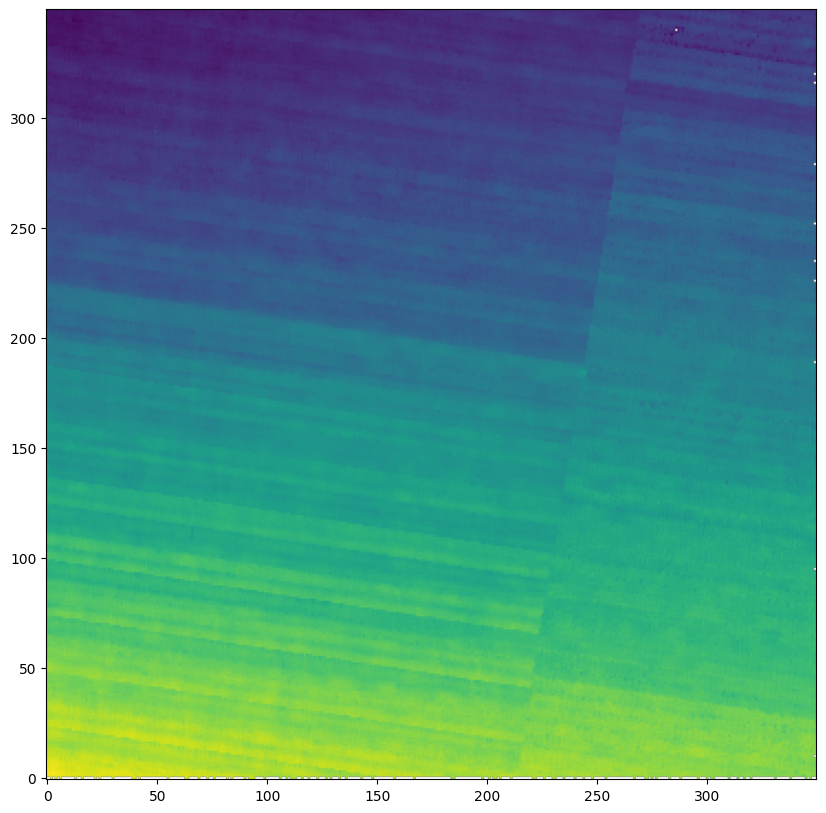

In [5]:
#rasterize the points in the bbox and plot the raster

points = gpd.GeoDataFrame(
    points_in_bbox,
    geometry=gpd.points_from_xy(points_in_bbox["Easting_N31"], points_in_bbox["Northing_N31"]),
    crs="EPSG:32631",
)

shapes = ((geom, value) for geom, value in zip(points.geometry, points["Mean (m)"]))

cell_size = 20
x_min, x_max, y_min, y_max = bbox
width = int((x_max - x_min) / cell_size)
height = int((y_max - y_min) / cell_size)

transform = rtransform.from_bounds(x_min+5, y_min+5, x_max+5, y_max+5, width, height)


raster = rfeatures.rasterize(
    shapes=shapes, 
    out_shape=(height, width),
    transform=transform,
    fill=np.nan,
    all_touched=True,
    dtype='float32'
)

plt.figure(figsize=(10, 10))
plt.imshow(raster, origin='lower', cmap='viridis')

In [6]:
# extract 2d data in numpy array

array = raster.astype('float32')
# fill nan values using nearest neighbor interpolation
from scipy import ndimage
array_filled = ndimage.generic_filter(array, np.nanmean, size=3, mode='nearest')


In [111]:
from destriping import polynomial_fit

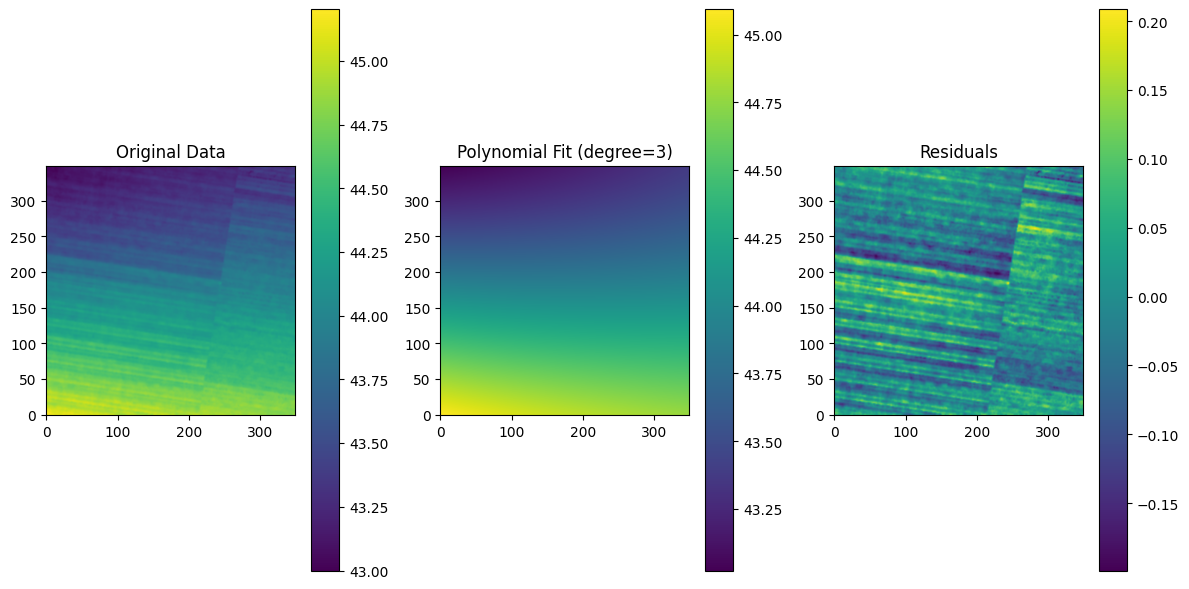

array([[45.09395585, 45.09261624, 45.09127969, ..., 44.77629926,
        44.77570229, 44.77510653],
       [45.08830038, 45.08696588, 45.08563445, ..., 44.77237195,
        44.77177983, 44.77118892],
       [45.08263045, 45.08130106, 45.07997474, ..., 44.76843128,
        44.76784401, 44.76725795],
       ...,
       [43.02783646, 43.02846293, 43.02909221, ..., 43.37656921,
        43.37784675, 43.37912524],
       [43.02381154, 43.02444424, 43.02507974, ..., 43.3746581 ,
        43.3759416 , 43.37722605],
       [43.0198106 , 43.02044952, 43.02109125, ..., 43.37277208,
        43.37406155, 43.37535195]], shape=(350, 350))

In [ ]:
polynomial_fit(array_filled, degree=3, plot=True)


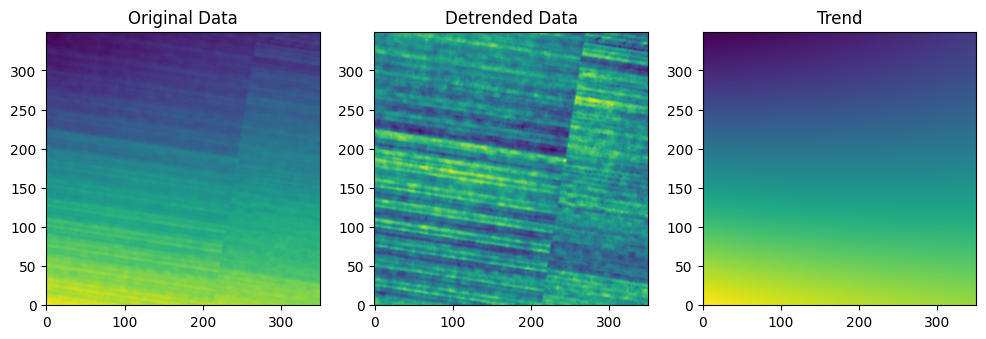

In [49]:
data = array_filled

ny, nx = data.shape
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
XY = np.column_stack((x.ravel(), y.ravel()))

poly = PolynomialFeatures(3)  # quadratic detrend
XY_poly = poly.fit_transform(XY)

model = LinearRegression().fit(XY_poly, data.ravel())
trend = model.predict(XY_poly).reshape(data.shape)

detrended = data - trend

# plt the original and detrended data
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("Original Data")
plt.imshow(data, origin='lower', cmap='viridis')
plt.subplot(1, 3, 2)
plt.title("Detrended Data")
plt.imshow(detrended, origin='lower', cmap='viridis')
plt.subplot(1, 3, 3)
plt.title("Trend")
plt.imshow(trend, origin='lower', cmap='viridis')
plt.show()

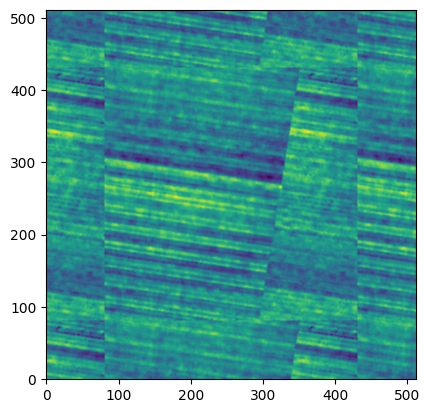

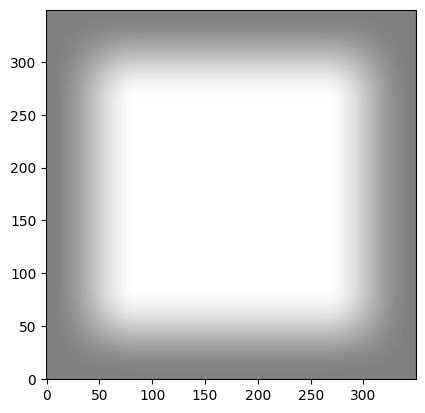

In [119]:
ny, nx = detrended.shape

wx = sig.windows.tukey(nx, alpha=0.5)
wy = sig.windows.tukey(ny, alpha=0.5)
window = np.outer(wy, wx)
window_safe = np.clip(window, 1e-2, 1)  # avoid division by zero

data_windowed = detrended # * window_safe

# pad to nearest power of 2
n_pad_x = 2**int(np.ceil(np.log2(nx)))
n_pad_y = 2**int(np.ceil(np.log2(ny)))
# Calculate padding to center the data
pad_y_before = (n_pad_y - ny) // 2
pad_y_after = n_pad_y - ny - pad_y_before
pad_x_before = (n_pad_x - nx) // 2
pad_x_after = n_pad_x - nx - pad_x_before

data_padded = np.pad(
    data_windowed,
    ((pad_y_before, pad_y_after), (pad_x_before, pad_x_after)),
    mode='wrap'
)

plt.imshow(data_padded, origin='lower', cmap='viridis')
plt.figure()
plt.imshow(window_safe, origin='lower', cmap='gray', alpha=0.5)

In [120]:

F = np.fft.fftshift(np.fft.fft2(data_padded))

# 2. Build frequency grids
ny_pad, nx_pad = data_padded.shape
kx = np.linspace(-0.5, 0.5, nx_pad)
ky = np.linspace(-0.5, 0.5, ny_pad)
KX, KY = np.meshgrid(kx, ky)

# 3. Find the stripe frequency direction manually or visually
# Example: horizontal stripes → notch vertical frequency band
# Adjust how much you notch with bandwidth (bw)
bw = 0.02  # try very small values first
notch = 1 - np.exp(-(KX**2)/(2*bw**2))

# 4. Apply notch (multiplicative)
F_filtered = F * notch

# 5. Inverse FFT
filtered = np.real(np.fft.ifft2(np.fft.ifftshift(F_filtered)))


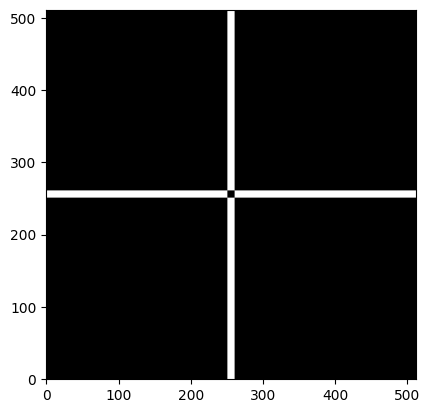

In [121]:
notch = np.zeros_like(data_padded)
notchy, notchx = notch.shape
width = 5
notch[notchy//2-width:notchy//2+width, :] = 1
notch[:, notchx//2-width:notchx//2+width] = 1
notch[notchy//2-width:notchy//2+width, notchx//2-width:notchx//2+width] = 0

plt.imshow(notch, origin='lower', cmap='gray')

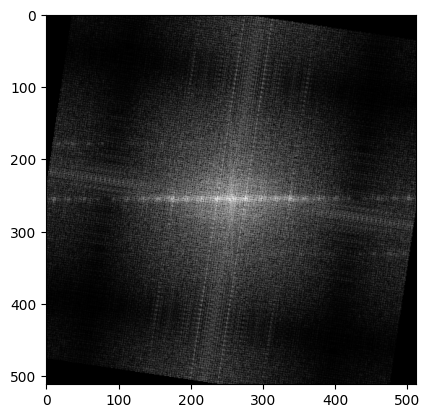

In [122]:
max_angle = 0
max_response = 0 
for angle in np.arange(0, 90, .5):
    rotated = ndimage.rotate(F, angle=angle, reshape=False)
    response = np.sum(np.abs(rotated)*notch)
    if response > max_response:
        max_response = response
        max_angle = angle

rotated = ndimage.rotate(F, angle=max_angle, reshape=False)
plt.imshow(np.log(np.abs(rotated) + 1), cmap='gray')

rotated_filtered = rotated * (1-notch)
F_filtered = ndimage.rotate(rotated_filtered, angle=-max_angle, reshape=False)
filtered = np.real(np.fft.ifft2(np.fft.ifftshift(F_filtered)))

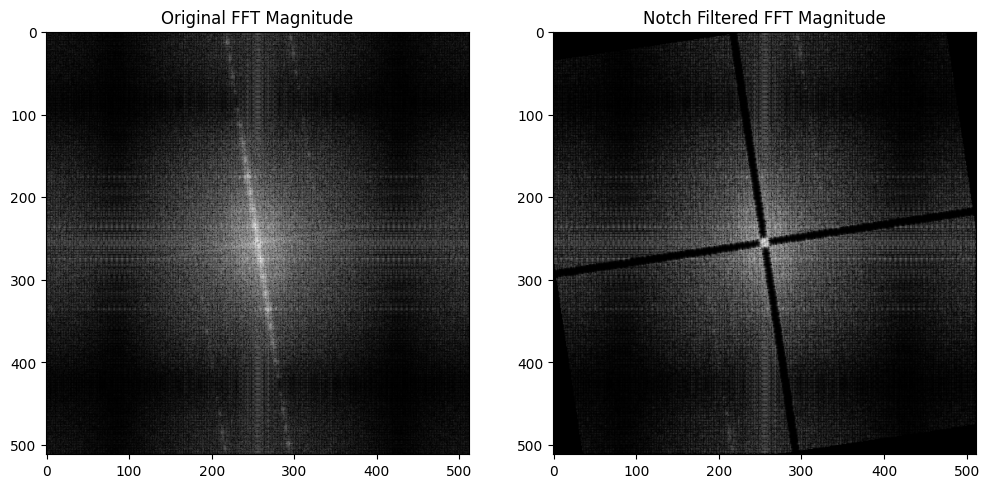

In [123]:
# plot F
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original FFT Magnitude")
plt.imshow(np.log(np.abs(F) + 1), cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Notch Filtered FFT Magnitude")
plt.imshow(np.log(np.abs(F_filtered) + 1), cmap='gray')
plt.show()

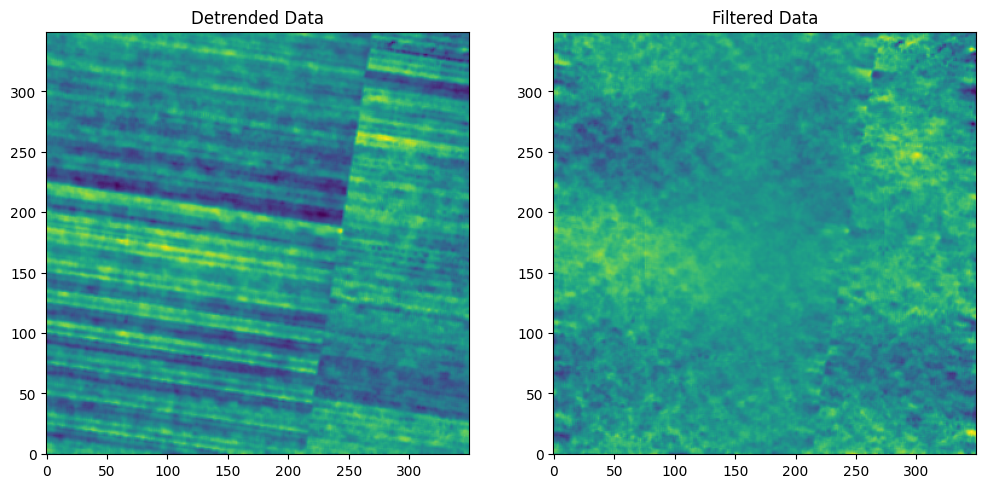

In [124]:
# ...existing code...
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Detrended Data")
plt.imshow(detrended, origin='lower', cmap='viridis')
# remove the padding from the filtered result
filtered_nopad = filtered[pad_y_before:pad_y_before+ny, pad_x_before:pad_x_before+nx] 
plt.subplot(1, 2, 2)
plt.title("Filtered Data")
plt.imshow(filtered_nopad, origin='lower', cmap='viridis')
# ...existing code...

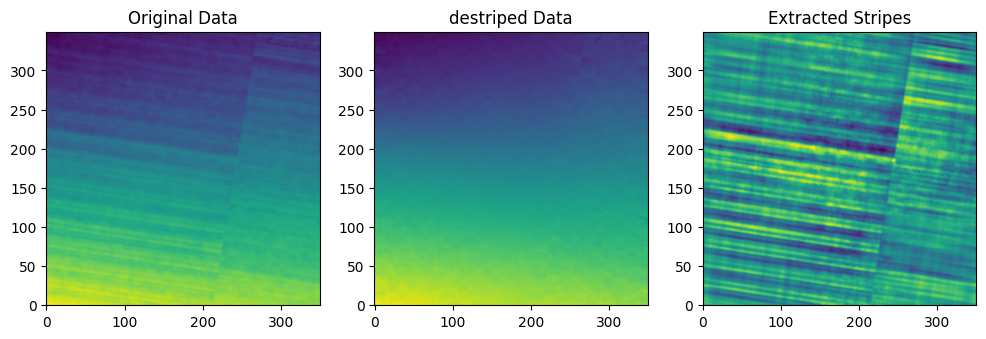

In [125]:
destriped = filtered_nopad + trend
stripes = data - destriped

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("Original Data")
plt.imshow(data, origin='lower', cmap='viridis')
plt.subplot(1, 3, 2)
plt.title("destriped Data")
plt.imshow(destriped, origin='lower', cmap='viridis')
plt.subplot(1, 3, 3)
plt.title("Extracted Stripes")
plt.imshow(stripes, origin='lower', cmap='viridis') 


In [130]:
from destriping import destripe_raster

In [ ]:
destripe_raster(data, trend_param=3, plot=True)

In [132]:
meta

Data Set name                                                  Friesland Junction
Discipline                               Marine geology (DS04)|Terrestrial (DS08)
Category                        Gravity, magnetics and bathymetry (G005)|Terre...
Variables measured                                 Bathymetry and Elevation(MBAN)
Data format                                                                   xyz
Data format version                                                           1.0
Data size                                                                53770721
Data Set creation Date                                                   20220420
Latitude 1                                                               3.710981
Latitude 2                                                               5.009963
Longitude 1                                                             53.919651
Longitude 2                                                             54.100639
Datum           